# Self-Accelerating Airy Beam Benchmark

This notebook demonstrates the **Airy beam benchmark** — a key test case for
**non-compact** fields where domain-enlargement requires source regeneration
(not zero-padding).

We will:
1. Set up a finite-energy 2D Airy beam
2. Propagate to multiple distances and observe the self-acceleration trajectory
3. Track the peak intensity coordinate vs. z
4. Visualise the power spectrum of a non-compact field
5. Run validation to see how diagnostics flag non-compact fields

In [8]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Build the Airy beam contract

The 2D Airy beam is:
$$U(x,y) = \mathrm{Ai}\!\left(\frac{x}{x_0}\right) e^{a x/x_0} \cdot
           \mathrm{Ai}\!\left(\frac{y}{x_0}\right) e^{a y/x_0}$$

where $x_0 = 20\;\mu\text{m}$ is the transverse scale and $a = 0.05$ is the
decay parameter that ensures finite energy.

**Key property**: this field does NOT have compact spatial support —
the oscillating Airy tail extends to $-\infty$.

In [9]:
from propagation_sanity.benchmarks.accelerating_beam import build_airy_beam_contract

contract = build_airy_beam_contract(
    z=10e-3,
    scale=20e-6,  # x₀ = 20 μm
    decay=0.05,  # a = 0.05
    nx=256,
    ny=256,
    dx=2e-6,
    dy=2e-6,
    wavelength=532e-9,
)

print(f"Grid:     {contract.grid}")
print(f"Wave:     {contract.wave}")
print(f"Compact:  {contract.source.compact_support}")
print(f"Scale:    {contract.source.scale*1e6:.0f} μm")

Grid:     Grid(256×256, dx=2.000 μm, L=0.5120×0.5120 mm)
Wave:     Wave(λ=532.0 nm)
Compact:  False
Scale:    20 μm


## 2. Visualise the input Airy beam

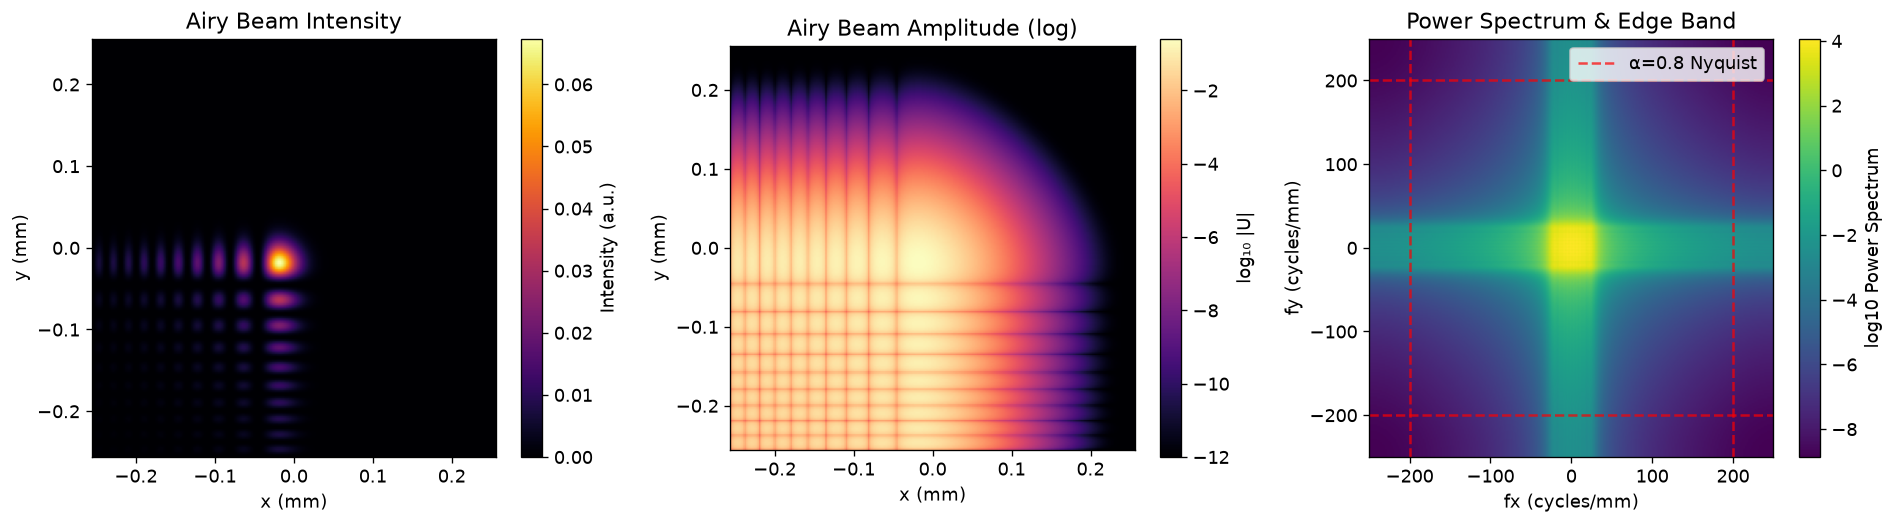

In [10]:
from propagation_sanity.plotting import plot_field_intensity, plot_spectrum_with_nyquist

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Intensity
plot_field_intensity(contract.field, title="Airy Beam Intensity", ax=axes[0])

# Amplitude (log scale)
grid = contract.field.grid
extent = [-grid.Lx / 2 * 1e3, grid.Lx / 2 * 1e3, -grid.Ly / 2 * 1e3, grid.Ly / 2 * 1e3]
im = axes[1].imshow(
    np.log10(contract.field.amplitude + 1e-12),
    extent=extent, origin="lower", cmap="magma",
)
axes[1].set_aspect("equal")
axes[1].set_box_aspect(1)
plt.colorbar(im, ax=axes[1], label="log₁₀ |U|",
             fraction=0.046, pad=0.04)
axes[1].set_title("Airy Beam Amplitude (log)")
axes[1].set_xlabel("x (mm)")
axes[1].set_ylabel("y (mm)")

# Power spectrum
plot_spectrum_with_nyquist(contract.field, alpha=0.8, ax=axes[2])

fig.tight_layout()
plt.show()

## 3. Propagation: self-acceleration trajectory

The hallmark of the Airy beam is transverse self-acceleration:
the main lobe shifts along a parabolic trajectory as it propagates.

The theoretical deflection is:
$$\Delta x(z) = \frac{1}{4 k^2 x_0^3} z^2$$

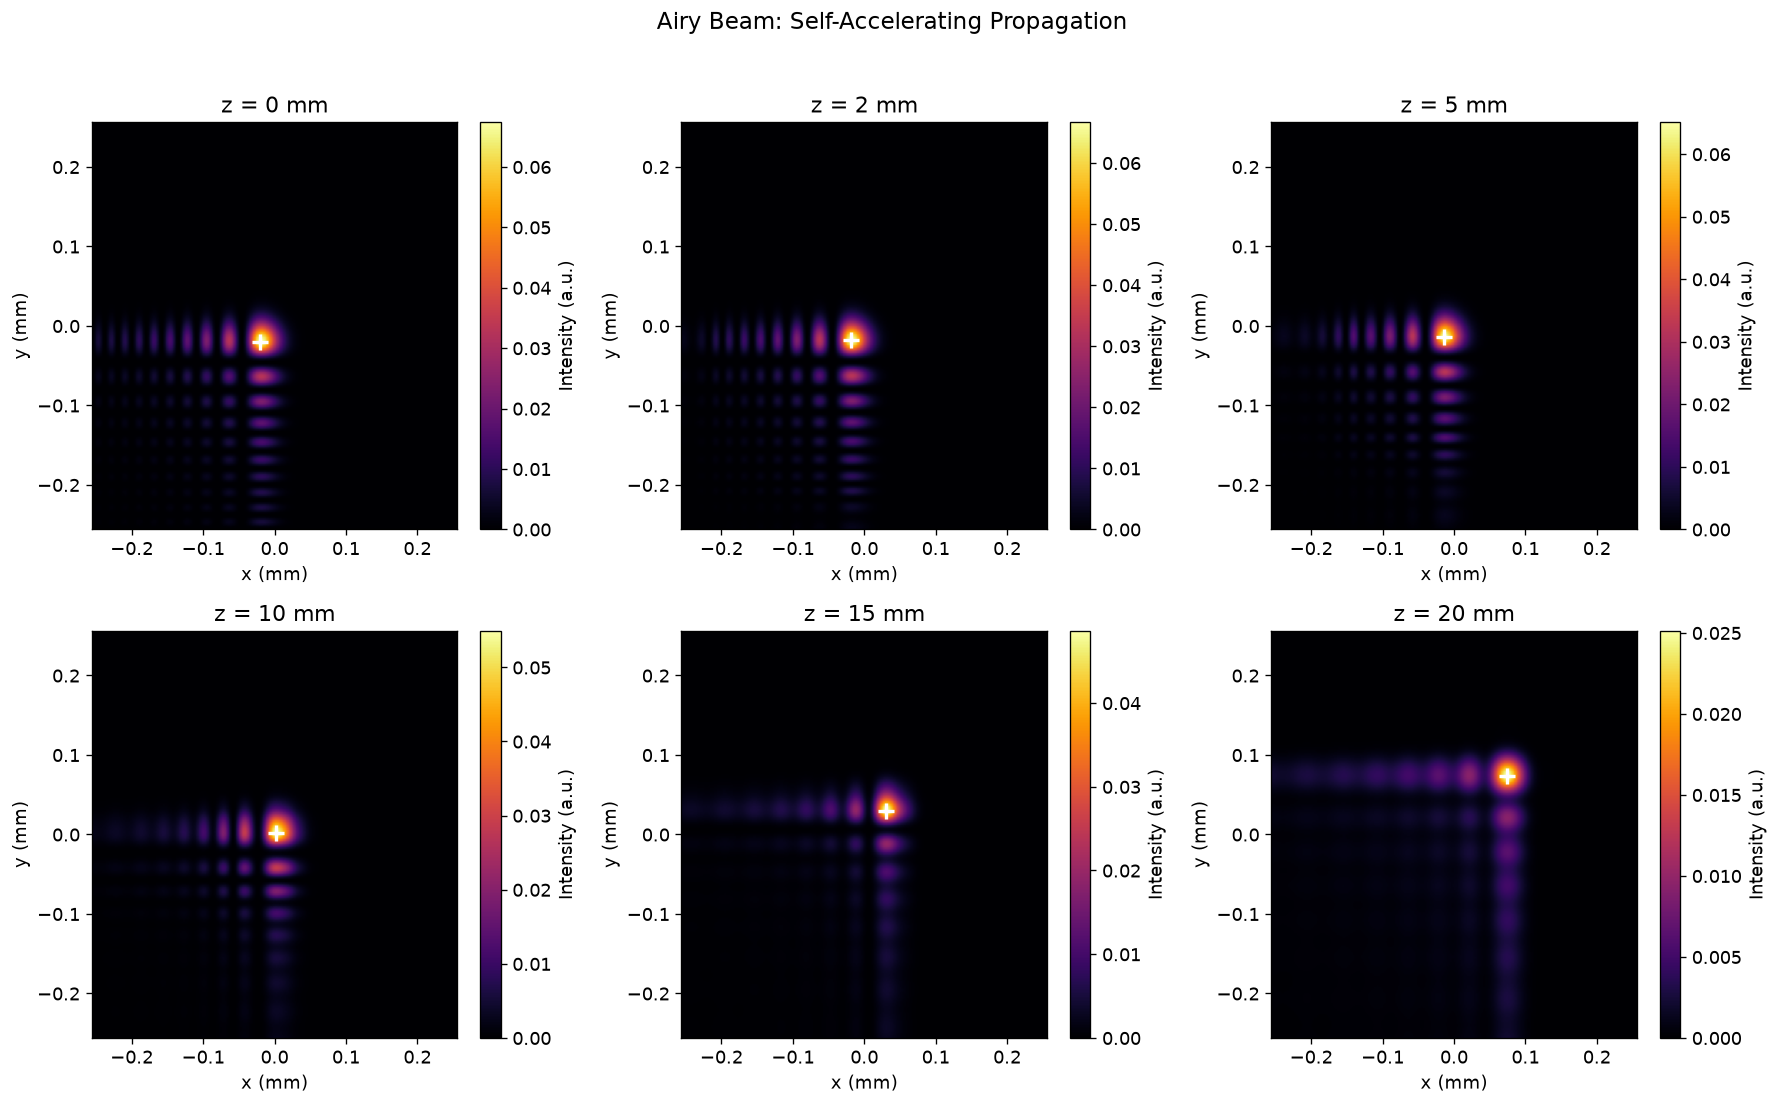

In [11]:
from propagation_sanity.adapters.waveprop_adapter import WavepropAdapter

adapter = WavepropAdapter()
z_list = [0.0, 2e-3, 5e-3, 10e-3, 15e-3, 20e-3]

peak_x_list = []
peak_y_list = []

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, z_val in enumerate(z_list):
    ax = axes.ravel()[i]
    c = build_airy_beam_contract(z=z_val)

    if z_val == 0.0:
        field_out = c.field
        out_grid = c.grid
    else:
        res = adapter.propagate(c.field, c.wave, z_val, c.propagation_config)
        field_out = res.field
        out_grid = res.output_grid

    # Track peak
    intensity = field_out.intensity
    peak_idx = np.unravel_index(np.argmax(intensity), intensity.shape)
    peak_x = float(out_grid.x_coords()[peak_idx[1]])
    peak_y = float(out_grid.y_coords()[peak_idx[0]])
    peak_x_list.append(peak_x)
    peak_y_list.append(peak_y)

    plot_field_intensity(field_out, title=f"z = {z_val*1e3:.0f} mm", ax=ax)
    ax.plot(peak_x * 1e3, peak_y * 1e3, "w+", ms=10, mew=2)  # mark peak

fig.suptitle("Airy Beam: Self-Accelerating Propagation", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 4. Peak trajectory plot

Compare the numerical peak location with the theoretical parabolic trajectory.

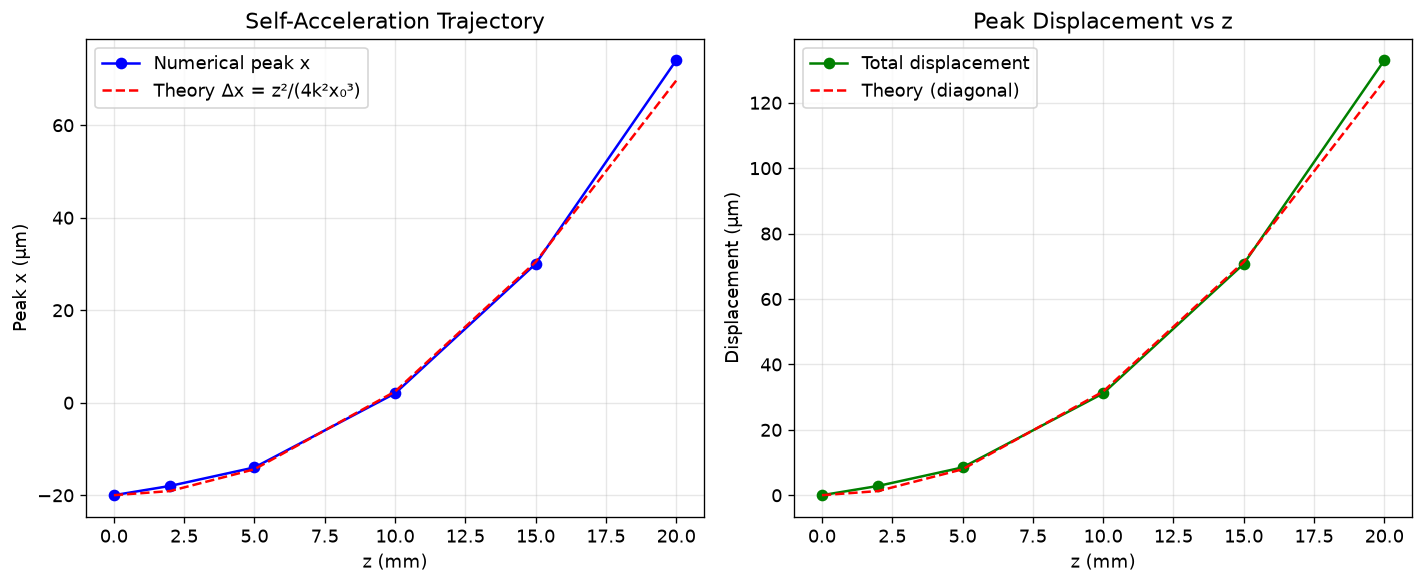

In [12]:
z_arr = np.array(z_list)
peak_x_arr = np.array(peak_x_list)
peak_y_arr = np.array(peak_y_list)

# Theoretical trajectory: Δx = z² / (4 k² x₀³)
k = contract.wave.k_medium
x0 = contract.source.scale
delta_theory = z_arr**2 / (4 * k**2 * x0**3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# X-trajectory
ax1.plot(z_arr * 1e3, peak_x_arr * 1e6, "bo-", label="Numerical peak x")
ax1.plot(
    z_arr * 1e3,
    (peak_x_arr[0] + delta_theory) * 1e6,
    "r--",
    label="Theory Δx = z²/(4k²x₀³)",
)
ax1.set_xlabel("z (mm)")
ax1.set_ylabel("Peak x (μm)")
ax1.set_title("Self-Acceleration Trajectory")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Peak displacement
displacement = np.sqrt(
    (peak_x_arr - peak_x_arr[0]) ** 2 + (peak_y_arr - peak_y_arr[0]) ** 2
)
ax2.plot(z_arr * 1e3, displacement * 1e6, "go-", label="Total displacement")
ax2.plot(z_arr * 1e3, delta_theory * np.sqrt(2) * 1e6, "r--", label="Theory (diagonal)")
ax2.set_xlabel("z (mm)")
ax2.set_ylabel("Displacement (μm)")
ax2.set_title("Peak Displacement vs z")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 5. Validation report for non-compact field

Key things to observe:
- **Boundary energy**: should be elevated (Airy tail reaches the edge)
- **Spectral edge energy**: may show content near Nyquist
- **compact_support = False**: domain convergence requires regeneration

In [13]:
from propagation_sanity.validate import validate

contract_10mm = build_airy_beam_contract(z=10e-3)
report = validate(contract_10mm, run_convergence=False)

print(report.summary())

NUMERICAL PROPAGATION VALIDATION

Simulation
----------------------------------------
  nx                    256
  ny                    256
  dx                    2.0000e-06
  dy                    2.0000e-06
  Lx                    5.1200e-04
  Ly                    5.1200e-04
  wavelength            5.3200e-07
  z                     0.01
  method                asm

Derived
----------------------------------------
  nx                    256
  ny                    256
  dx                    2.0000e-06
  dy                    2.0000e-06
  Lx                    5.1200e-04
  Ly                    5.1200e-04
  dfx                   1953.125000
  dfy                   1953.125000
  nyquist_x             2.5000e+05
  nyquist_y             2.5000e+05

Diagnostics
----------------------------------------
  Spectral edge energy  2.3008e-06
  Effective bandwidth   {'radial': {'95.0%': 30508.78779651037, '99.0%': 35854.60888805824, '99.9%': 46095.40516096073}, 'x': {'95.0%': 23437.5, '99.

## 6. Output power spectrum evolution

Track how the spectral content evolves with propagation distance.

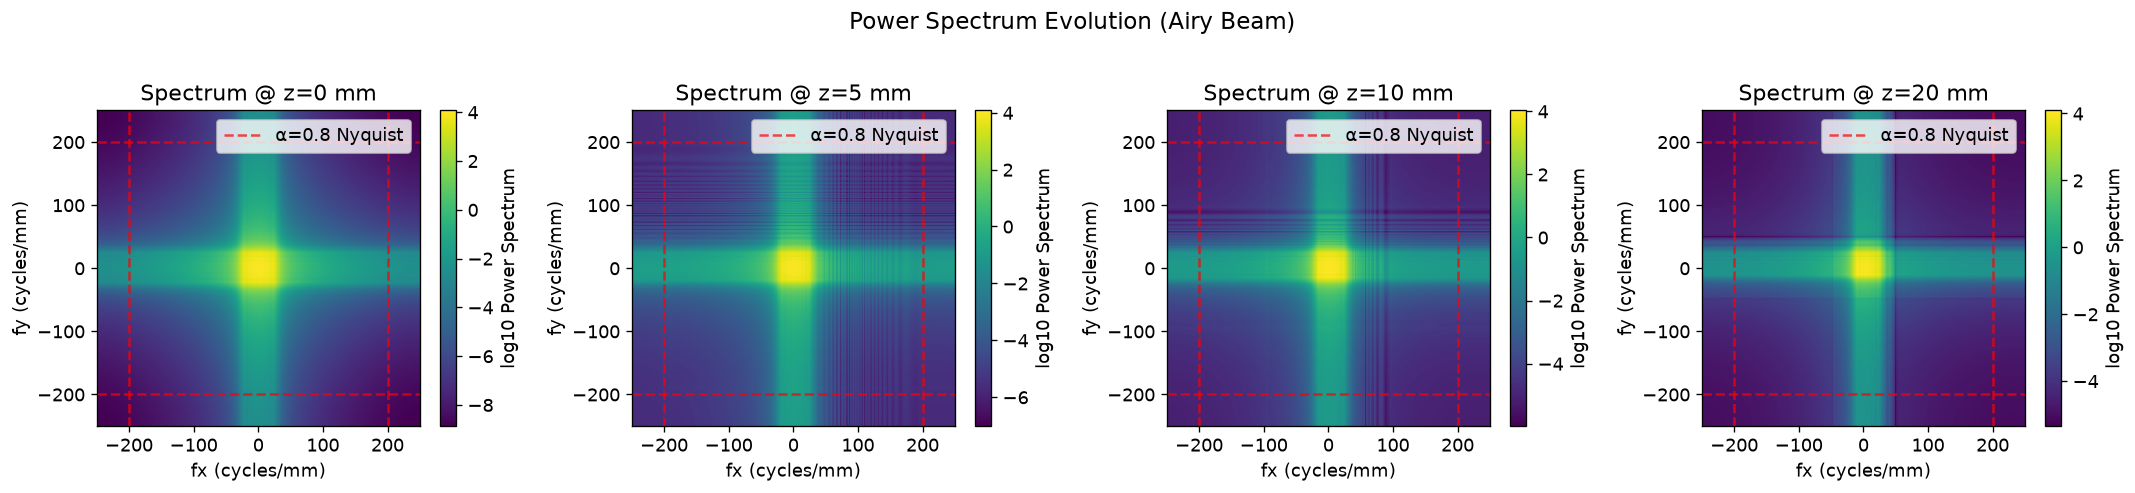

In [14]:
z_spectrum = [0.0, 5e-3, 10e-3, 20e-3]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, z_val in zip(axes, z_spectrum):
    c = build_airy_beam_contract(z=z_val)
    if z_val == 0.0:
        field_out = c.field
    else:
        res = adapter.propagate(c.field, c.wave, z_val, c.propagation_config)
        field_out = res.field

    plot_spectrum_with_nyquist(field_out, alpha=0.8, ax=ax)
    ax.set_title(f"Spectrum @ z={z_val*1e3:.0f} mm")

fig.suptitle("Power Spectrum Evolution (Airy Beam)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Key takeaways

1. **Non-compact fields need regeneration**: The Airy beam's oscillating
   tail extends to infinity.  For domain convergence, you must call
   `source.sample(larger_grid)` — zero-padding the existing array gives
   a physically wrong result.

2. **Self-acceleration is visible**: The main lobe clearly shifts along
   a parabolic trajectory, confirming the propagation is working.

3. **Boundary energy warns of truncation**: The diagnostics correctly
   flag the non-negligible field amplitude at the grid edge.

4. **Spectral leakage**: The power spectrum of a truncated Airy beam
   shows spectral artefacts near the Nyquist boundary.